# Micro-models: audyt danych i pierwsze treningi

**26 września 2026, Europe/Warsaw.** Reprodukowalny przegląd rzeczywistych danych
i wyników zapisanych w tej paczce. Jednostką podziału jest grupa powiązanych
utworów, a nie okno tekstu. Test oglądamy wyłącznie strukturalnie; **nie liczymy
na nim jakości modeli**. Ten notebook nie trenuje ani nie dobiera modeli.

Uruchomienie: rozpakuj całą paczkę, zainstaluj `requirements-lock.txt` i otwórz
ten notebook z katalogu projektu. Pełne kontrole źródła i parsera są w
`src/double_check.py`; do ich powtórzenia potrzebny jest przypięty korpus źródłowy.
Notebook ponownie oblicza zestawienia z rekordów oraz sprawdza hashe i wyniki audytu.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
from fractions import Fraction
import hashlib, json, math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if not (ROOT / 'data/manifest.json').exists():
    ROOT = ROOT / 'micro_models_training_20260926'
assert (ROOT / 'data/manifest.json').exists(), 'Rozpakuj pełną paczkę obok notebooka.'
def read_json(path): return json.loads((ROOT / path).read_text())
def sha(path): return hashlib.sha256(path.read_bytes()).hexdigest()
def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '|' + '|'.join(['---'] * len(headers)) + '|']
    lines += ['| ' + ' | '.join(str(x) for x in row) + ' |' for row in rows]
    display(Markdown('\n'.join(lines)))

splits = ['train', 'validation', 'test']
labels = {'train':'Trening', 'validation':'Walidacja', 'test':'Test odłożony'}
colors = {'train':'#2378AE', 'validation':'#E49B25', 'test':'#3B927A'}
data = {s:[json.loads(l) for l in (ROOT / f'data/{s}.jsonl').read_text().splitlines()] for s in splits}
manifest = read_json('data/manifest.json')
audit = read_json('audit/double_check.json')
manifest_hash = sha(ROOT / 'data/manifest.json')
assert manifest_hash == audit['manifest_sha256']
assert sha(ROOT / 'src/protocol.py') == audit['protocol_sha256']
assert sha(ROOT / 'src/double_check.py') == audit['audit_script_sha256']
for s in splits:
    assert sha(ROOT / f'data/{s}.jsonl') == manifest['data_files'][f'{s}.jsonl']
assert audit['passed'] and all(audit['checks'].values())
assert audit['test_loss_computed'] is False
print('Manifest SHA-256:', manifest_hash)
print('Kontrole drugiego audytu:', sum(audit['checks'].values()), '/', len(audit['checks']))
plt.rcParams.update({'font.size':10, 'axes.spines.top':False, 'axes.spines.right':False,
                     'figure.dpi':120, 'savefig.dpi':160})
(ROOT / 'figures').mkdir(exist_ok=True)

Manifest SHA-256: 92c0801ccc5f9b0e099d17209e675c0fbeb3d8cbed0b0994990e3a1d1868da5f
Kontrole drugiego audytu: 19 / 19


## Pochodzenie, deduplikacja i podział

Źródło: Craig Stuart Sapp, *A digital edition of 370 J.S. Bach Chorales* (2009),
[bach-370-chorales](https://github.com/craigsapp/bach-370-chorales), commit
`0fd9e00542445a522c6030c80c687b874aa569d5`, **CC BY-NC-SA 4.0**.
Adaptacja: sopran, ABC, bez tekstu pieśni i ekspresji; jedno przejście bez
rozwijania repetycji. Dokładność wysokości i długości sprawdzona przez odczyt ABC.

370 zapisów źródłowych → 18 usuniętych dokładnych powtórzeń sopranu → **352 melodie**.
Powiązania według tytułów, rdzeni BWV, tożsamości i transpozycji melodii, długich
fragmentów oraz podobnego przebiegu interwałów tworzą **169 grup**.
Losowanie i poprawki podziału wykorzystały tylko metadane, nigdy błędy modeli.

In [2]:
total = sum(map(len, data.values()))
summary = []
for s, rows in data.items():
    summary.append([labels[s], len(rows), len({r['family_id'] for r in rows}),
                    sum(len(r['text']) for r in rows), f'{100*len(rows)/total:.2f}%',
                    int(np.median([len(r['text']) for r in rows]))])
table(['Zbiór','Melodie','Grupy','Znaki ABC','Udział melodii','Mediana długości'], summary)
assert total == 352
assert sum(len({r['family_id'] for r in rows}) for rows in data.values()) == 169

| Zbiór | Melodie | Grupy | Znaki ABC | Udział melodii | Mediana długości |
|---|---|---|---|---|---|
| Trening | 281 | 135 | 67016 | 79.83% | 219 |
| Walidacja | 36 | 17 | 8664 | 10.23% | 216 |
| Test odłożony | 35 | 17 | 8299 | 9.94% | 226 |

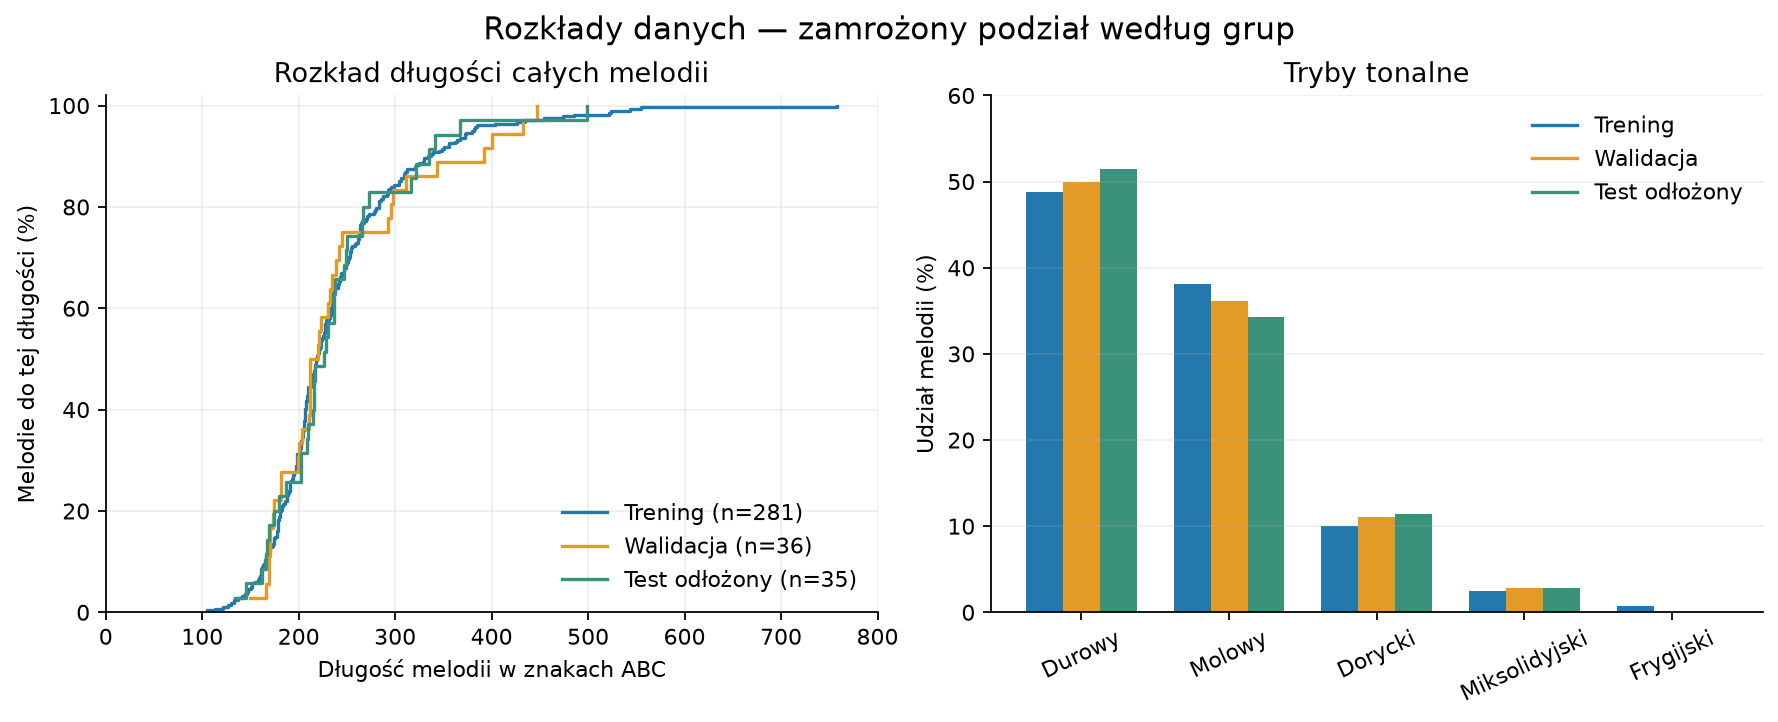

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), layout='constrained')
for s, rows in data.items():
    values = np.sort([len(r['text']) for r in rows])
    axes[0].step(values, np.arange(1, len(values)+1)/len(values)*100,
                 where='post', color=colors[s], label=f'{labels[s]} (n={len(rows)})')
    axes[1].plot([], [], color=colors[s], label=labels[s])
axes[0].set(xlabel='Długość melodii w znakach ABC', ylabel='Melodie do tej długości (%)',
            title='Rozkład długości całych melodii', xlim=(0,800), ylim=(0,102))
axes[0].grid(alpha=.2); axes[0].legend(frameon=False, loc='lower right')
modes = ['major','minor','dorian','mixolydian','phrygian']
mode_names = ['Durowy','Molowy','Dorycki','Miksolidyjski','Frygijski']
x = np.arange(len(modes)); width=.25
for j, s in enumerate(splits):
    counts = Counter(r['mode'] for r in data[s])
    heights = [counts[m]/len(data[s])*100 for m in modes]
    axes[1].bar(x+(j-1)*width, heights, width, color=colors[s])
axes[1].set(xticks=x, xticklabels=mode_names, ylabel='Udział melodii (%)',
            title='Tryby tonalne', ylim=(0,60))
axes[1].tick_params(axis='x', labelrotation=25)
axes[1].legend(frameon=False); axes[1].grid(axis='y',alpha=.2)
fig.suptitle('Rozkłady danych — zamrożony podział według grup', fontsize=14)
fig.savefig(ROOT / 'figures/distributions.png', bbox_inches='tight')
display(Image(filename=str(ROOT / 'figures/distributions.png')))
plt.close(fig)

In [4]:
for field, title in [('mode','Tryb'), ('meter','Metrum'), ('key_sharps','Znaki przykluczowe')]:
    keys = sorted({r[field] for rows in data.values() for r in rows}, key=str)
    table([title]+[labels[s] for s in splits],
          [[k]+[sum(r[field]==k for r in data[s]) for s in splits] for k in keys])
table(['Odchylenie od całego korpusu','Walidacja','Test'], [
    ['Jensen–Shannon rozkładu znaków (bity)'] +
    [f"{audit['details']['distribution']['characters'][s]['jensen_shannon_bits']:.6f}" for s in ['validation','test']],
    ['Total variation trybów tonalnych'] +
    [f"{audit['details']['distribution']['mode'][s]['total_variation']:.4f}" for s in ['validation','test']],
    ['Total variation metrum'] +
    [f"{audit['details']['distribution']['meter'][s]['total_variation']:.4f}" for s in ['validation','test']]])

| Tryb | Trening | Walidacja | Test odłożony |
|---|---|---|---|
| dorian | 28 | 4 | 4 |
| major | 137 | 18 | 18 |
| minor | 107 | 13 | 12 |
| mixolydian | 7 | 1 | 1 |
| phrygian | 2 | 0 | 0 |

| Metrum | Trening | Walidacja | Test odłożony |
|---|---|---|---|
| 3/2 | 1 | 0 | 0 |
| 3/4 | 28 | 4 | 3 |
| 4/4 | 252 | 32 | 32 |

| Znaki przykluczowe | Trening | Walidacja | Test odłożony |
|---|---|---|---|
| -1 | 39 | 5 | 5 |
| -2 | 42 | 5 | 5 |
| -3 | 12 | 2 | 2 |
| -4 | 2 | 0 | 1 |
| 0 | 63 | 7 | 8 |
| 1 | 54 | 6 | 6 |
| 2 | 37 | 7 | 5 |
| 3 | 27 | 3 | 3 |
| 4 | 5 | 1 | 0 |

| Odchylenie od całego korpusu | Walidacja | Test |
|---|---|---|
| Jensen–Shannon rozkładu znaków (bity) | 0.002086 | 0.002844 |
| Total variation trybów tonalnych | 0.0196 | 0.0378 |
| Total variation metrum | 0.0117 | 0.0166 |

Nie wymuszamy idealnie identycznych rozkładów. Dwa utwory frygijskie i jedno
metrum 3/2 występują tylko w treningu. To ogranicza zakres oceny. Walidacja i test
mają po 17 grup; liczba znaków nie jest liczbą niezależnych obserwacji.
Największa grupa ma 79 melodii powiązanych pośrednio, nie 79 dokładnych duplikatów.

In [5]:
pitch = {s:Counter(e[0] for r in rows for e in r['events'] if e[0] is not None)
         for s, rows in data.items()}
duration = {s:Counter(str(Fraction(e[1],e[2])) for r in rows for e in r['events'])
            for s, rows in data.items()}
musical = {}
for s in ['validation','test']:
    unseen_durations = sorted(set(duration[s])-set(duration['train']), key=Fraction)
    musical[s] = {'unseen_pitches':sorted(set(pitch[s])-set(pitch['train'])),
                  'unseen_durations_quarter_notes':{d:duration[s][d] for d in unseen_durations},
                  'events_with_unseen_duration':sum(duration[s][d] for d in unseen_durations),
                  'total_events':sum(duration[s].values())}
table(['Zbiór','Zakres MIDI','Nowe wysokości','Nowe długości; liczba zdarzeń'],
      [[labels[s], f'{min(pitch[s])}–{max(pitch[s])}', str(musical[s]['unseen_pitches']),
        str(musical[s]['unseen_durations_quarter_notes'])] for s in ['validation','test']])
(ROOT/'audit/musical_support.json').write_text(json.dumps(musical, indent=2)+'\n')

Out[5]: 374


| Zbiór | Zakres MIDI | Nowe wysokości | Nowe długości; liczba zdarzeń |
|---|---|---|---|
| Walidacja | 60–81 | [] | {'1/8': 4, '7': 1} |
| Test odłożony | 60–81 | [] | {'1/8': 4, '14': 1} |

Długości powyżej są w ćwierćnutach po scaleniu łuków i obejmują też pauzy.
Brak części długości w treningu jest jawnym sprawdzianem rzadkich kombinacji,
nie brakiem tokenu: wszystkie znaki walidacji i testu występują w treningu.
Nie zmieniamy z tego powodu zamrożonego podziału.

## Double check: przeciek, konwersja i metryka

Pierwszy próg podobieństwa 88% nie połączył bliskiej pary o innych tytułach
(`chor130`, `chor320`, około 82%). Unieważniono wstępne treningi, zaostrzono próg
do 80%, ponownie wykonano podział i audyt, a modele uruchomiono od losowych wag.
Drugie sprawdzenie wykorzystuje `difflib.SequenceMatcher`, podczas gdy grupowanie
wykorzystuje RapidFuzz. Jest to oddzielna implementacja kontroli, nie opinia
drugiego człowieka. Żadne stare wagi nie weszły do wyników poniżej.

In [6]:
hash_fields = ['id','family_id','text_sha256','melody_sha256','transposed_sha256']
overlap_rows = []
for a,b in combinations(splits,2):
    counts = [len({r[k] for r in data[a]} & {r[k] for r in data[b]}) for k in hash_fields]
    assert not any(counts)
    overlap_rows.append([labels[a]+' / '+labels[b]]+counts)
table(['Para','ID','Grupy','Tekst','Melodia','Transpozycja'], overlap_rows)
table(['Kontrola drugiego audytu','Wynik'],
      [[k, 'PASS' if v else 'FAIL'] for k,v in audit['checks'].items()])
table(['Para zbiorów','Najwyższe podobieństwo interwałów','Najbliższa para'],
      [[k, f"{100*v['maximum_alternative_contour_similarity']:.2f}%", ', '.join(v['nearest_pair'])]
       for k,v in audit['details']['nearest_cross_split_pairs'].items()])

| Para | ID | Grupy | Tekst | Melodia | Transpozycja |
|---|---|---|---|---|---|
| Trening / Walidacja | 0 | 0 | 0 | 0 | 0 |
| Trening / Test odłożony | 0 | 0 | 0 | 0 | 0 |
| Walidacja / Test odłożony | 0 | 0 | 0 | 0 | 0 |

| Kontrola drugiego audytu | Wynik |
|---|---|
| unique_representative_ids | PASS |
| all_370_sources_accounted_once | PASS |
| all_source_hashes_match | PASS |
| all_record_lengths_match | PASS |
| all_text_hashes_match | PASS |
| no_unrecognized_characters | PASS |
| headers_do_not_contain_identity | PASS |
| soprano_is_highest_mean_voice | PASS |
| zero_overlap_train:validation | PASS |
| zero_overlap_train:test | PASS |
| zero_overlap_validation:test | PASS |
| character_JS_under_0_06_bits | PASS |
| mode_TV_under_0_15 | PASS |
| meter_TV_under_0_15 | PASS |
| split_shares_within_5_percentage_points | PASS |
| ABC_roundtrip_all_pitches_and_durations | PASS |
| all_targets_once_no_tail_omission_no_record_crossing | PASS |
| uniform_metric_matches_analytic_value_all_lengths | PASS |
| causal_mask_does_not_expose_future_tokens | PASS |

| Para zbiorów | Najwyższe podobieństwo interwałów | Najbliższa para |
|---|---|---|
| train:validation | 65.75% | chor090, chor040 |
| train:test | 70.45% | chor326, chor144 |
| validation:test | 61.54% | chor073, chor068 |

W pełnym audycie zerowe przecięcia dotyczą także aliasów tytułów, rdzeni BWV,
fragmentów 128 znaków, fragmentów 24 interwałów i bliskich całych konturów.
Wszystkie 352 konwersje zachowały wysokości i dokładne długości. Każdy znak
walidacji jest oceniany raz, łącznie z końcówką i pierwszym znakiem po BOS.
Okna nie przekraczają granicy utworu. Zmiana przyszłych tokenów nie zmienia
wcześniejszych logitów GPT.

Wynik: **nie wykryto przecieku w zakresie zapisanych reguł**. Nie jest to dowód
wykluczający wszystkie relacje muzykologiczne; krótkie wspólne motywy są naturalne.

In [7]:
cases = audit['details']['uniform_metric_matches_analytic_value_all_lengths']
table(['Długość','Ocenione znaki','PPL modelu jednostajnego (oczekiwane 82)'],
      [[r['chars'],r['scored'],f"{r['ppl']:.6f}"] for r in cases])
assert all(r['chars']==r['scored'] and abs(r['ppl']-82)<1e-4 for r in cases)

| Długość | Ocenione znaki | PPL modelu jednostajnego (oczekiwane 82) |
|---|---|---|
| 1 | 1 | 81.999997 |
| 2 | 2 | 81.999997 |
| 63 | 63 | 81.999997 |
| 64 | 64 | 81.999997 |
| 65 | 65 | 81.999997 |
| 127 | 127 | 81.999997 |
| 128 | 128 | 81.999997 |
| 129 | 129 | 81.999997 |
| 130 | 130 | 81.999997 |
| 191 | 191 | 81.999997 |
| 192 | 192 | 81.999997 |
| 193 | 193 | 81.999997 |
| 255 | 255 | 81.999997 |
| 256 | 256 | 81.999997 |
| 257 | 257 | 81.999997 |
| 1000 | 1000 | 81.999997 |

## Rzeczywiste treningi i walidacja

Architektura GPT pochodzi bez zmian z [slayerlabs/micro-models](https://github.com/slayerlabs/micro-models),
commit `da30da3d7486a4b6b3de8d2d4aaa0f183617f751`. Słownik 82-tokenowy daje
820 224 parametry. NPLM: 78 866 parametrów, historia 16 znaków.
Modele neuronowe: FP32, CPU, po 2000 aktualizacji, batch 32, warmup i kosinusowy lr.
Dwa seedy GPT badają wrażliwość na inicjalizację; nie są strojeniem na teście.

**PPL części muzycznej** = exp(sumy NLL / liczby znaków części muzycznej).
Nagłówek ABC pozostaje kontekstem, ale jego przewidywalne znaki nie obniżają tej
głównej metryki. Niżej = mniejszy błąd predykcji znaków; nie oznacza automatycznie
lepszej muzyki. PPL całego ABC pokazujemy osobno.

Pole `order` n-gramu to długość historii: konteksty 1/3/6 oznaczają do 2/4/7-gramów.
Checkpointy wybrano według pełnej walidacji co 200 kroków. To wyniki użyte przy
wyborze, nie niezależna ocena testowa. Nie porównujemy ich wprost z README upstream.

In [8]:
results = []
ngram = read_json(f'runs/ngram_{manifest_hash[:8]}/validation.json')
assert ngram['manifest_sha256']==manifest_hash and not ngram['test_evaluated']
for r in ngram['results']:
    results.append({'model':f"N-gram: kontekst {r['order']}", 'parameters':None,
                    'best_step':None, 'val_body_ppl':r['body_ppl'], 'val_full_ppl':r['ppl'],
                    'train_body_ppl':None, 'state':'completed', 'seed':None})
run_dirs = sorted((ROOT/'runs').glob('*_seed_*'))
neural = []
for run in run_dirs:
    if not run.is_dir(): continue
    status=json.loads((run/'status.json').read_text())
    cfg=json.loads((run/'config.json').read_text())
    val=json.loads((run/'best_validation.json').read_text())
    assert cfg['manifest_sha256']==manifest_hash and not status['test_evaluated']
    assert status['state']=='completed', 'Notebook końcowy wymaga ukończonych treningów.'
    name=f"{cfg['model_type'].upper()} / {cfg['seed']}"
    row={'model':name,'parameters':cfg['parameters'],'best_step':status['best_step'],
         'val_body_ppl':val['body_ppl'],'val_full_ppl':val['ppl'],
         'train_body_ppl':status['best_training_body_ppl'],'state':status['state'],
         'seed':cfg['seed'],'completed_steps':status['step'],
         'elapsed_seconds':status['elapsed_seconds'],'processed_target_tokens':status['processed_target_tokens'],
         'run_path':str(run.relative_to(ROOT))}
    results.append(row)
    events=[json.loads(l) for l in (run/'metrics.jsonl').read_text().splitlines()]
    neural.append((name,events))
table(['Model','Parametry','Najlepszy krok','PPL wal. muzyka','PPL wal. ABC','PPL tren. muzyka'],
      [[r['model'],r['parameters'] or '—',r['best_step'] if r['best_step'] is not None else '—',
        f"{r['val_body_ppl']:.4f}",f"{r['val_full_ppl']:.4f}",
        f"{r['train_body_ppl']:.4f}" if r['train_body_ppl'] else '—'] for r in results])
summary={'manifest_sha256':manifest_hash,'test_evaluated':False,'metric':'validation character perplexity, music body',
         'rows':results}
(ROOT/'runs/summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False)+'\n')

Out[8]: 2319


| Model | Parametry | Najlepszy krok | PPL wal. muzyka | PPL wal. ABC | PPL tren. muzyka |
|---|---|---|---|---|---|
| N-gram: kontekst 1 | — | — | 3.8358 | 3.8901 | — |
| N-gram: kontekst 3 | — | — | 2.7369 | 2.6053 | — |
| N-gram: kontekst 6 | — | — | 2.1955 | 2.0907 | — |
| GPT / 20260926 | 820224 | 1600 | 1.9828 | 1.8963 | 1.8383 |
| GPT / 20260927 | 820224 | 1800 | 1.9747 | 1.8888 | 1.8217 |
| NPLM / 20260926 | 78866 | 1200 | 1.8970 | 1.8202 | 1.5882 |

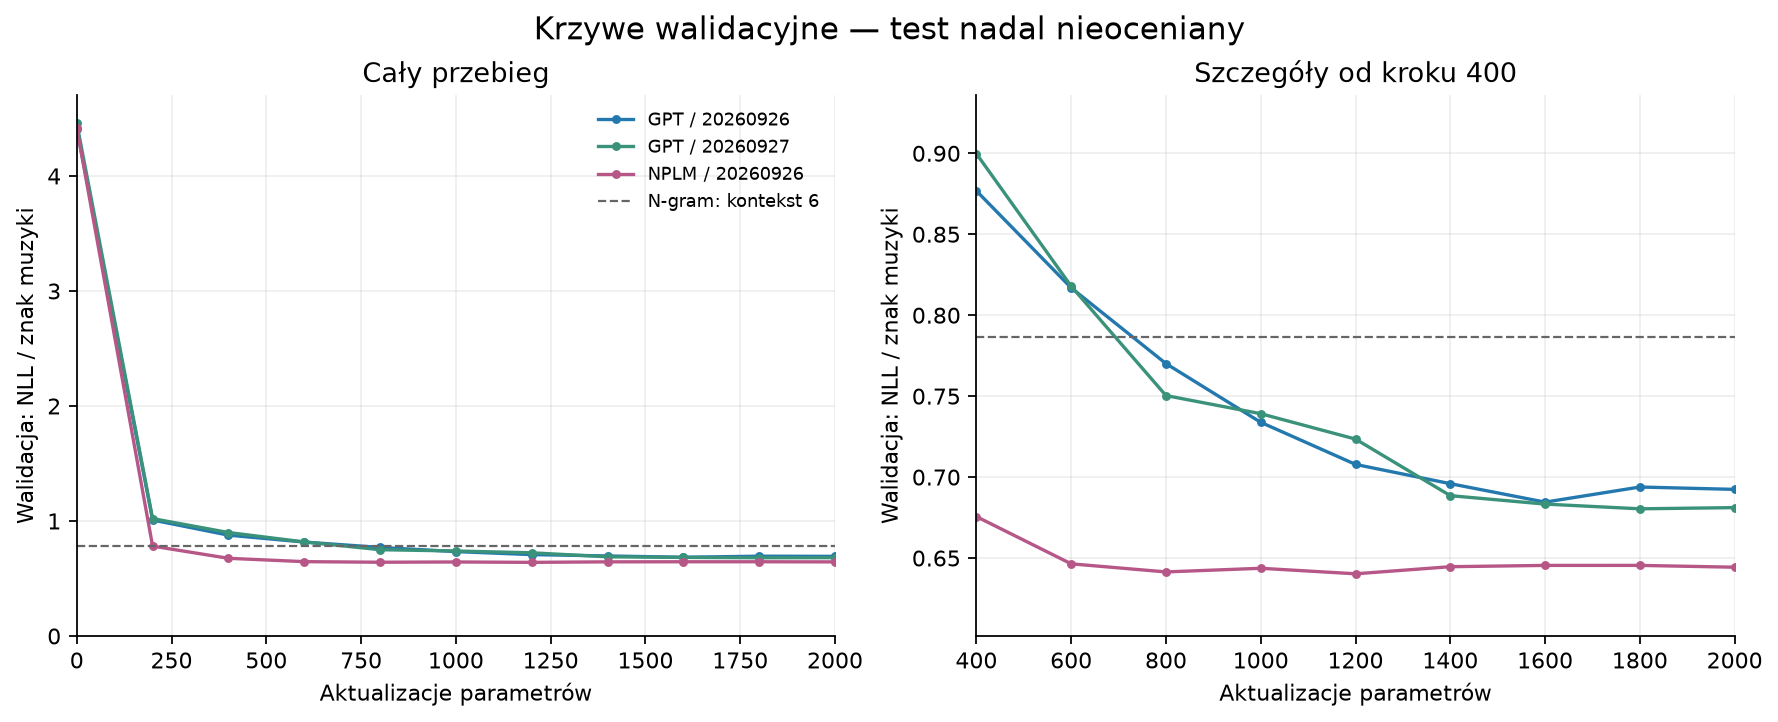

In [9]:
fig, axes = plt.subplots(1,2,figsize=(11,4.4),layout='constrained')
line_colors=['#2378AE','#3B927A','#B65787']
for (name, events), color in zip(neural,line_colors):
    x=[e['step'] for e in events]
    y=[e['validation']['body_nll_per_char'] for e in events]
    for ax in axes: ax.plot(x,y,marker='o',markersize=3,label=name,color=color)
baseline=next(r for r in ngram['results'] if r['order']==6)['body_nll_per_char']
for ax in axes:
    ax.axhline(baseline,color='#666666',linestyle='--',linewidth=1,label='N-gram: kontekst 6')
    ax.set(xlabel='Aktualizacje parametrów',ylabel='Walidacja: NLL / znak muzyki')
    ax.grid(alpha=.2)
axes[0].set(title='Cały przebieg',xlim=(0,2000),ylim=(0,4.7))
ys=[e['validation']['body_nll_per_char'] for _,ev in neural for e in ev if e['step']>=400]
axes[1].set(title='Szczegóły od kroku 400',xlim=(400,2000),ylim=(min(ys)*.94,max(ys)*1.04))
axes[0].legend(frameon=False,fontsize=8,loc='upper right')
fig.suptitle('Krzywe walidacyjne — test nadal nieoceniany',fontsize=14)
fig.savefig(ROOT/'figures/training_curves.png',bbox_inches='tight')
display(Image(filename=str(ROOT / 'figures/training_curves.png')))
plt.close(fig)

## Jak kontynuować

- Dane i reguły ewaluacji są zamrożone przez SHA-256. Każdy trener wymaga pozytywnego audytu.
- `checkpoint_last.pt` zawiera optymalizator i stany RNG; `checkpoint_best.pt` zachowuje najlepsze wagi walidacyjne.
- Dokładne komendy odtworzenia i wznowienia są w `README_PL.md`; logi i konfiguracje w `runs/`.
- Ten eksperyment obejmuje chorały Bacha. Dalsze korpusy stylów muzycznych i Obsidian potrzebują oddzielnych dostępnych danych oraz tego samego typu kontroli.
- Test pozostaje na końcową ocenę po zamrożeniu wyboru modeli. Nie należy dobierać kolejnych ustawień na podstawie jego przyszłego wyniku.
- Kolejne oceny muzykalności powinny sprawdzać składnię, metrum, frazy i odsłuch, a nie tylko perplexity.

Źródła i licencje: przypięte repozytoria powyżej, `licenses/` oraz metadane i hashe
każdego rekordu w `data/manifest.json`. Ten notebook korzysta wyłącznie z dostarczonych
danych i logów; nie pobiera nowych źródeł podczas wykonania.